Obs:
1. Trabalhar na branch da fase
2. git status
3. git add .
4. git commit -m "feat: ..."
5. git push
6. git checkout main
7. git pull origin main
8. git merge nome-da-branch
9. git push origin main
10. git checkout -b próxima-branch
✔ git status
✔ git add .
✔ git commit
✔ git push
✔ git checkout main
✔ git pull
✔ git merge
✔ git push origin main
✔ git checkout -b próxima-branch
✔ git push -u origin próxima-branch
Fase 1: Análise Exploratória de Dados (EDA) 


  Fase 1: 

* Descritiva e estatística


Importação das bibliotecas


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Carregamento dos dados e visualizar as primeiras linhas


In [95]:
df = pd.read_csv("credit_risk_dataset.csv")

print("Primeiras 5 linhas da base de dados:")
df.head()

Primeiras 5 linhas da base de dados:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Dimensões da base

In [96]:
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

Número de linhas: 32581
Número de colunas: 12


Informações gerais

In [97]:
print("Informações gerais da base:")
df.info()

Informações gerais da base:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


Após executar o método df.info(), conclui-se:
o DataFrame — tem 32.581 linhas (registros).
Cada linha representa uma pessoa e um pedido de empréstimo.

Classificação das colunas do DataFrame

* Colunas numéricas

person_age (int64) — idade da pessoa.

person_income (int64) — renda anual.

person_emp_length (float64) — anos de emprego; possui 895 valores ausentes.

loan_amnt (int64) — valor do empréstimo.

loan_int_rate (float64) — taxa de juros; possui 3.116 valores ausentes.

loan_status (int64) — status do empréstimo (codificado).

loan_percent_income (float64) — porcentagem da renda comprometida.

cb_person_cred_hist_length (int64) — anos de histórico de crédito.

* Colunas categóricas

person_home_ownership (object) — tipo de moradia.

loan_intent (object) — intenção do empréstimo.

loan_grade (object) — classificação do empréstimo.

cb_person_default_on_file (object) — registro de default (Y/N).

* Valores ausentes

“non-null” = valores presentes |
“entries” = total de linhas

Se non-null < entries, então existem valores faltantes.

person_emp_length → faltam 895 valores

loan_int_rate → faltam 3116 valores

Para melhor conduzir as explicações deste código, crio um dicionário:

In [98]:
dicionario_traducao = {
    'person_age': 'idade_pessoa',
    'person_income': 'renda_pessoa',
    'person_home_ownership': 'tipo_residencia',
    'person_emp_length': 'tempo_emprego',
    'loan_intent': 'finalidade_emprestimo',
    'loan_grade': 'classificacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'percentual_renda_comprometida',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'tempo_historico_credito'
}
df = df.rename(columns=dicionario_traducao)

Sumário Estatístico Descritivo

In [99]:
print("Resumo estatístico das variáveis numéricas:")
df.describe()

Resumo estatístico das variáveis numéricas:


,idade_pessoa,renda_pessoa,tempo_emprego,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_comprometida,tempo_historico_credito
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


As métricas que o Pandas mostra no resumo estatístico:

count → contagem de valores não nulos na coluna.

mean → média

std → desvio padrão: o quanto os dados “espalham” - indica o quanto os valores variam em relação à média.

min → mínimo: menor valor encontrado na coluna.

25% → 1º quartil (Q1): 25% dos valores são menores ou iguais a esse número.

50% → mediana (Q2): metade dos valores está abaixo e metade acima.

75% → 3º quartil (Q3): 75% dos valores são menores ou iguais a esse número.

max → máximo: maior valor encontrado na coluna.


Fase 1: 

* Visual - histograma de distribuição de idades/valores

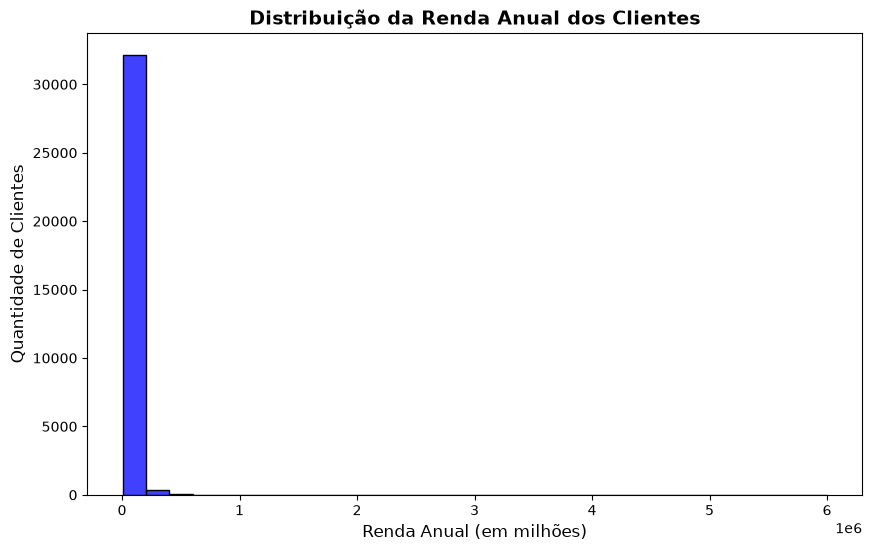

In [100]:
plt.figure(figsize=(10,6))

# Criar o histograma
#sns.histplot(data=df, x="renda_pessoa", bins=30, color="skyblue")
sns.histplot(data=df, x="renda_pessoa", bins=30, color="blue", edgecolor="black")

# Títulos e rótulos
plt.title("Distribuição da Renda Anual dos Clientes", fontsize=14, fontweight="bold")
plt.xlabel("Renda Anual (em milhões)", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

# gráfico
plt.show()

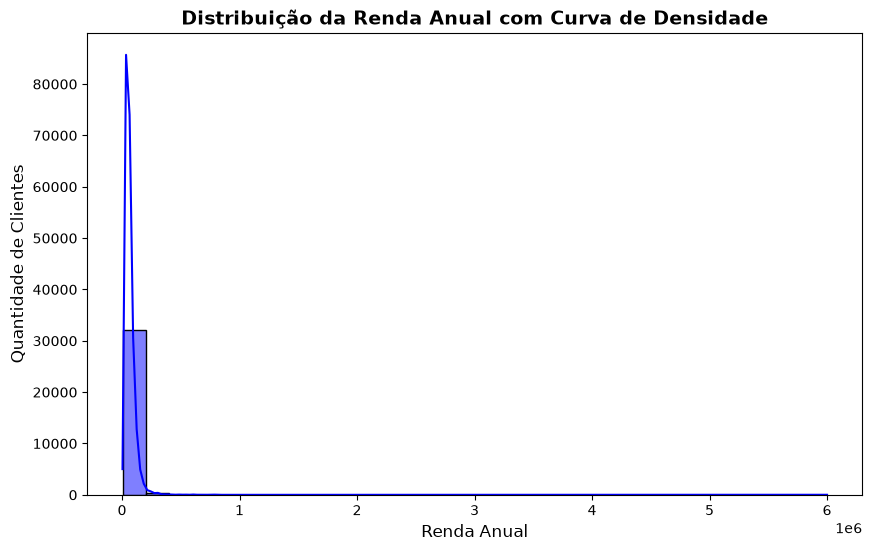

In [101]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="renda_pessoa", bins=30, kde=True,
             color="blue", edgecolor="black")
plt.title("Distribuição da Renda Anual com Curva de Densidade", fontsize=14, fontweight="bold")
plt.xlabel("Renda Anual", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)
plt.show()

Verificado que este gráfico precisa de ajustes para melhor análise, sendo assim, redefini as escalas como explicado:

Os quartis mostram que 25% dos clientes têm renda até cerca de R$ 38.500, indicando a faixa de menor renda.
A mediana, em torno de R$ 55.000, revela a renda típica da base. Os 75% dos clientes ganham até aproximadamente R$ 79.200, mostrando que rendas mais altas são menos frequentes. Os valores acima disso representam a cauda da distribuição, composta por poucos clientes com renda muito elevada.
Decidi criar dois conjuntos, pois o Histograma é uma ferramenta poderosa visualmente.

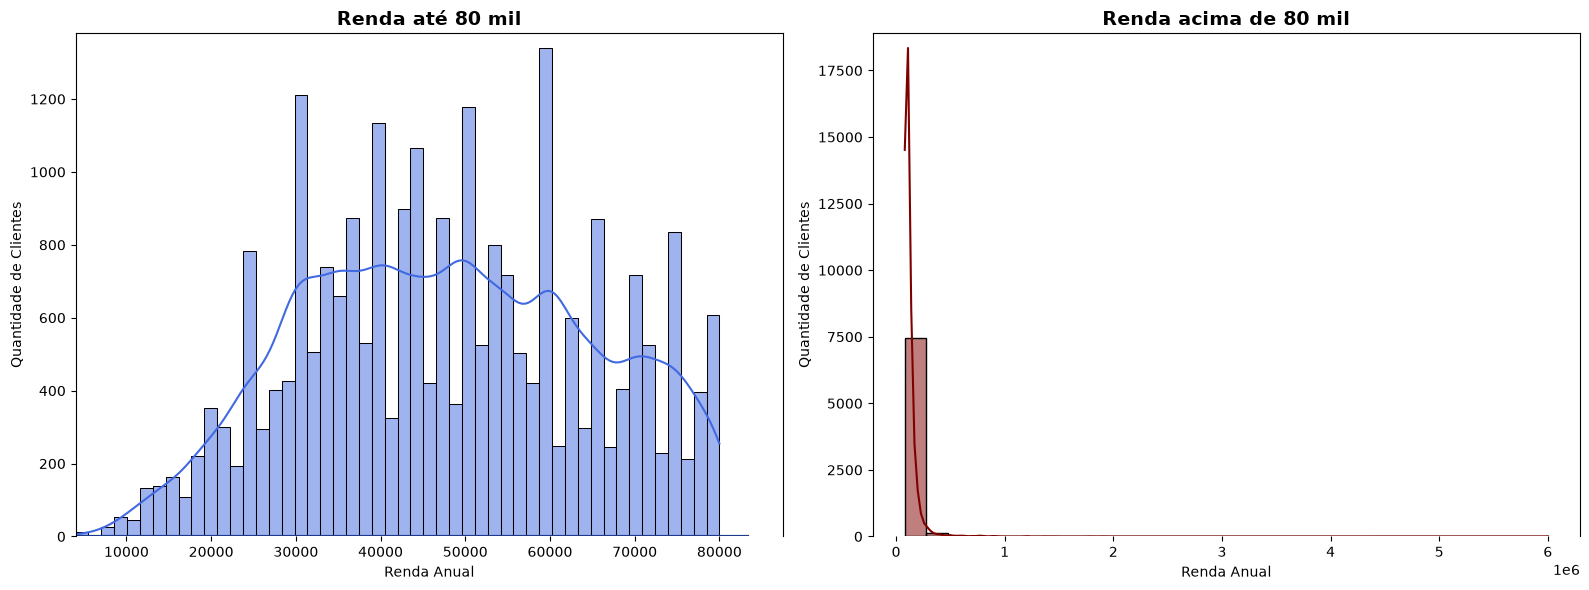

In [102]:
# Criar dois conjuntos
df_ate_80k = df[df['renda_pessoa'] <= 80000]
df_acima_80k = df[df['renda_pessoa'] > 80000]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Histograma até 80 mil 
sns.histplot(
    data=df_ate_80k,
    x="renda_pessoa",
    bins=50, kde=True,
    color="#4169E1",  
    edgecolor="black",
    ax=axes[0]
)
sns.kdeplot(
    df_ate_80k['renda_pessoa'],
    color="#1E3A8A",
    bw_adjust=0.5,
    ax=axes[0]
)
axes[0].set_title("Renda até 80 mil", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Renda Anual")
axes[0].set_ylabel("Quantidade de Clientes")
axes[0].spines['bottom'].set_color('none')
axes[0].margins(y=0.03)
axes[0].set_xlim(left=df['renda_pessoa'].min())

# Histograma acima de 80 mil 
sns.histplot(
    data=df_acima_80k,
    x="renda_pessoa",
    bins=30, kde=True,
    color="#800000",  
    edgecolor="black",
    ax=axes[1]
)
sns.kdeplot(
    df_ate_80k['renda_pessoa'],
    color="#1E3A8A",
    bw_adjust=0.5,
    ax=axes[0]
)
axes[1].set_title("Renda acima de 80 mil", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Renda Anual")
axes[1].set_ylabel("Quantidade de Clientes")
axes[1].spines['bottom'].set_color('none')
axes[1].margins(y=0.03)

plt.tight_layout()
plt.show()

A linha KDE representa a estimativa contínua da densidade dos dados, a tendência geral da distribuição de renda.
No gráfico até 80 mil, a curva evidencia maior concentração entre 30 000 e 60 000, indicando que essa faixa reúne a maioria dos clientes. Já no gráfico acima de 80 mil, a curva despenca rapidamente, revelando que rendas elevadas são raras e formam uma cauda longa à direita.
essa visualização complementa o histograma ao destacar a forma **assimétrica** da distribuição e a presença de poucos valores extremos.

  Fase 1: 

* Visual - gráfico de barras provando o desbalanceamento da variável alvo: (alvo: loan_status = 1) ou se pagará o empréstimo em dia (alvo: loan_status = 0), ou seja, 'status_emprestimo'.

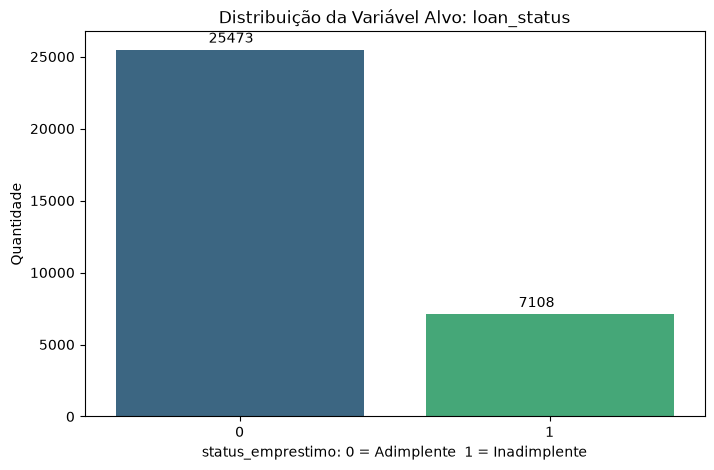

In [103]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    x='status_emprestimo',
    data=df,
    hue='status_emprestimo',
    palette='viridis',
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

plt.title('Distribuição da Variável Alvo: loan_status')
plt.xlabel('status_emprestimo: 0 = Adimplente  1 = Inadimplente')
plt.ylabel('Quantidade')
plt.show()

O gráfico de barras mostra que a **variável alvo é desbalanceada, com a classe 0 representando a maior parte dos registros**. O modelo, se treinado sem correções, tenderá a prever a classe predominante, resultando em métricas artificialmente altas e baixa capacidade de identificar corretamente a classe minoritária.

  Fase 1: 

* Visual - mapa de calor de correlação de Pearson

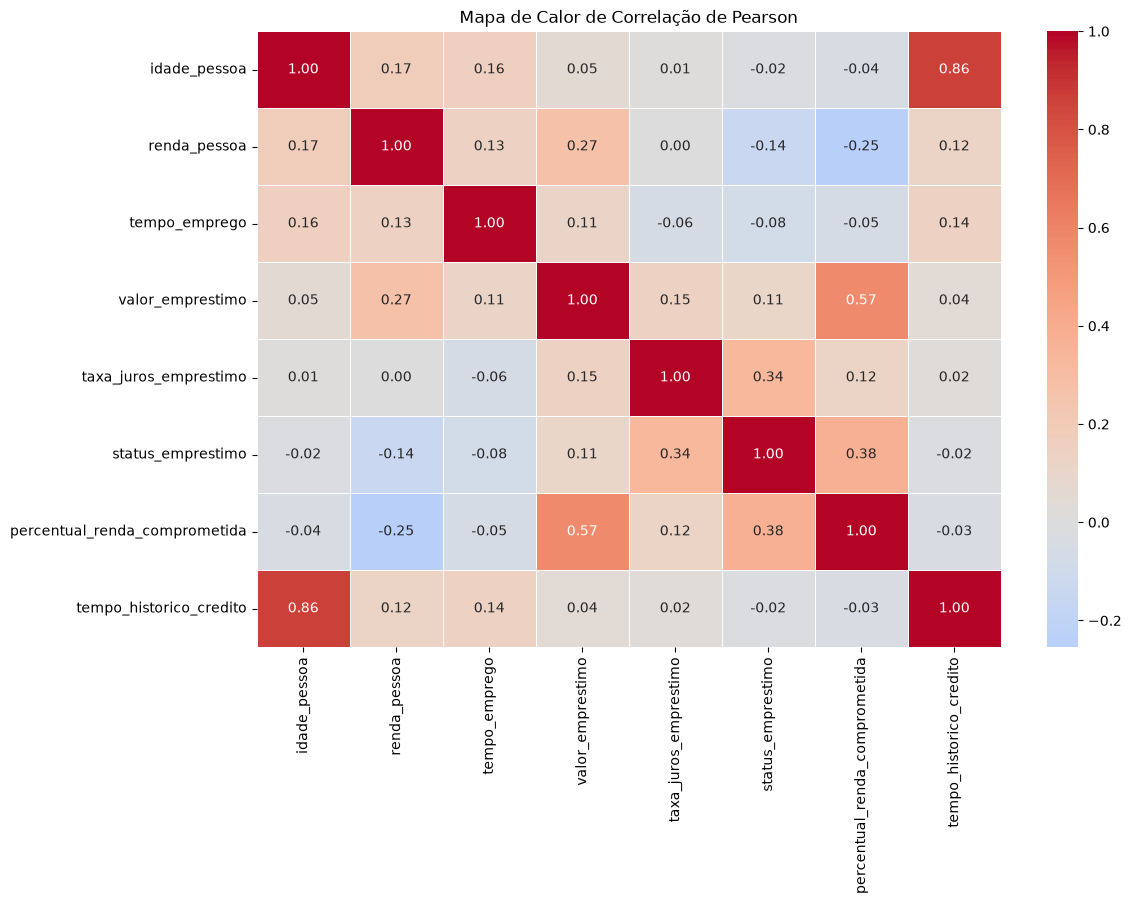

In [104]:
# Calcula a matriz de correlação
corr = df.corr(numeric_only=True)

# Define o tamanho e estilo do gráfico
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title('Mapa de Calor de Correlação de Pearson')
plt.show()

**Interpretações do Gráfico acima**:

1.Relações entre variáveis e alvo (status_emprestimo)
percentual_renda_comprometida → correlação positiva com inadimplência (Essa variável mede quanto do salário a pessoa compromete com o empréstimo.)
Quanto maior o percentual da renda comprometida, maior a chance de inadimplência. 

taxa_juros_emprestimo → correlação positiva com inadimplência. 

valor_emprestimo → correlação moderada com inadimplência Quanto maior o valor do empréstimo, maior o risco. 

renda_pessoa → correlação negativa com inadimplência Renda maior → menor risco. Clientes com renda mais alta têm mais capacidade de pagar.

idade_pessoa → correlação fraca Idade não é um grande preditor isolado.

tempo_emprego → correlação fraca/moderada Tempo de emprego maior tende a reduzir risco. Estabilidade profissional diminui inadimplência.

tempo_historico_credito → correlação fraca Histórico de crédito mais longo geralmente indica maturidade financeira, sozinho não é tão forte quanto renda ou percentual comprometido.

2.Relações entre variáveis (multicolinearidade)

valor_emprestimo vs percentual_renda_comprometida → correlação forte Empréstimos maiores comprometem maior parte da renda.
Isso significa: Essas duas variáveis carregam informação parecida. O modelo pode ficar redundante se ambas forem usadas sem cuidado.

renda_pessoa vs percentual_renda_comprometida → correlação negativa forte. Quanto maior a renda, menor o percentual comprometido.

O mapa de calor revela que as variáveis Percentual da Renda Comprometida, Taxa de Juros do Empréstimo e Valor do Empréstimo apresentam correlação positiva com o Status do Empréstimo, indicando que clientes com maior comprometimento de renda, juros mais altos ou empréstimos maiores tendem a ser mais inadimplentes.
Renda do Cliente apresenta correlação negativa com o alvo, sugerindo que rendas maiores reduzem o risco de calote.
Observa-se multicolinearidade entre as variáveis Valor do Empréstimo e Percentual da Renda Comprometida, que apresentam correlação elevada entre si. Isso indica que ambas carregam informação semelhante, o que pode gerar redundância e instabilidade em modelos baseados em distância, como o KNN.
Para modelos de Árvore de Decisão, essa multicolinearidade não representa risco, pois árvores são robustas a variáveis correlacionadas.

# Tomada de Decisão: Estratégia para a Preparação dos Dados

A análise estatística e os gráficos iniciais revelaram pontos críticos na nossa base de risco de crédito.

* Tratamento e limpeza (Fase 2):** Encontrei valores impossíveis na base, como idade de 144 anos e tempo de emprego de 123 anos, linhas com valores em branco (nulos). Corrigir isso é impoprtante, porque o modelo **KNN**, calcula a distância entre os pontos e é extremamente sensível a esses erros (outliers). Já a nossa **Árvore de Decisão** é bem mais resistente a esses valores distorcidos.
* Feature Engineering (Fase 3):** Criar a coluna calculada `comprometimento_renda`, que vai mostrar em formato de porcentagem o quanto do salário do cliente a parcela ocupa.
* Separação, Balanceamento e Escalonamento Seguro (Fase 4):** O gráfico de barras provou que a nossa variável alvo (`status_emprestimo`) é muito desbalanceada, tendo muito mais registros de pagamentos em dia do que de calotes. Para o modelo não ficar viciado em responder apenas que "o cliente vai pagar", balancear as classes no treino. Aplicar a padronização de escala (`StandardScaler`) apenas para o **KNN**, deixando a **Árvore de Decisão** sem esse ajuste, já que ela trabalha fazendo cortes lógicos e não depende do tamanho ou da escala dos números.


***

Fase 2: Tratamento e Limpeza (Data Prep)     
<br><br><br><br><br><br>
Fase 2:

* Duplicadas

In [105]:
print("Quantidade de linhas duplicadas:")

duplicadas = df.duplicated().sum()

print(duplicadas)

Quantidade de linhas duplicadas:
165


Remoção das duplicadas e verificação de linhas atuais.

In [106]:
duplicadas_antes = df.duplicated().sum()
print(f"Linhas duplicadas antes da remoção: {duplicadas_antes}")

# Remover duplicadas
df = df.drop_duplicates()

# Verificar novamente
duplicadas_depois = df.duplicated().sum()
total_linhas = df.shape[0]

print(f"Linhas duplicadas após a remoção: {duplicadas_depois}")
print(f"Total de linhas restantes no dataframe: {total_linhas}")

Linhas duplicadas antes da remoção: 165
Linhas duplicadas após a remoção: 0
Total de linhas restantes no dataframe: 32416


Realizada a verificação de duplicadas utilizando o método duplicated().
Antes da limpeza, a base apresentava 165 registros duplicados.
Após aplicar drop_duplicates(), o número de duplicadas foi reduzido para 0, garantindo que cada linha represente um cliente único.
O dataframe final passou a conter 32416 linhas válidas.

Fase 2

* Valores Nulos: Identifique as colunas com dados ausentes. É obrigatório justificar textualmente a escolha da técnica de imputação: usou a Média (indicada para distribuições normais/simétricas) ou a Mediana (indicada para mitigar o impacto de outliers)?

# Tratamento de Valores Nulos 

Ao executar o comando `df.info()`, identifiquei que as colunas `tempo_emprego` (person_emp_length) e `taxa_juros_emprestimo` (loan_int_rate) possuem dados ausentes (valores nulos).

A técnica escolhida para preencher esses dados ausentes será a **Imputação pela Mediana**. 
Justifico essa escolha porque, como vimos na análise exploratória, a base apresenta variáveis com distribuição assimétrica e indícios de valores extremos. Além disso, a coluna tempo_emprego apresenta um valor máximo muito superior ao terceiro quartil, indicando possível influência de outliers. Conforme pode ser observado na tabela a seguir, utilizo da mediana para imputação dos valores ausentes, por ser uma medida de tendência central mais robusta à presença de valores extremos, *outliers*.


In [107]:
estatisticas = df[['tempo_emprego', 'taxa_juros_emprestimo']].describe().T

estatisticas['Valores Nulos'] = (
    df[['tempo_emprego', 'taxa_juros_emprestimo']]
    .isnull()
    .sum()
)

estatisticas

,count,mean,std,min,25%,50%,75%,max,Valores Nulos
tempo_emprego,31529.0,4.790510,4.14549,0.00,2.0,4.00,7.00,123.00,887
taxa_juros_emprestimo,29321.0,11.017265,3.24168,5.42,7.9,10.99,13.47,23.22,3095


In [108]:
# Verificando a quantidade de valores nulos antes
print("Valores nulos antes da imputação:")
print(df[['tempo_emprego', 'taxa_juros_emprestimo']].isnull().sum())

# Imputação utilizando a mediana, por ser mais robusta à presença de valores extremos (outliers)
# e adequada para distribuições assimétricas.

df['tempo_emprego'] = df['tempo_emprego'].fillna(df['tempo_emprego'].median())
df['taxa_juros_emprestimo'] = df['taxa_juros_emprestimo'].fillna(df['taxa_juros_emprestimo'].median())

# Verificando a quantidade de valores nulos após a imputação
print("\nValores nulos após a imputação (O resultado deve ser 0):")
print(df[['tempo_emprego', 'taxa_juros_emprestimo']].isnull().sum())

Valores nulos antes da imputação:
tempo_emprego             887
taxa_juros_emprestimo    3095
dtype: int64

Valores nulos após a imputação (O resultado deve ser 0):
tempo_emprego            0
taxa_juros_emprestimo    0
dtype: int64


Fase 2

* Tratamento de Outliers: Identificar a presença de valores discrepantes na base (ex: via boxplots). O aluno deve tomar uma decisão fundamentada de tratamento (remoção, clipping ou manutenção). Nota pedagógica: Avalie o impacto disso nos modelos, lembrando que o KNN é extremamente sensível a outliers (muda as distâncias euclidianas), enquanto a Árvore de Decisão é robusta a eles. 

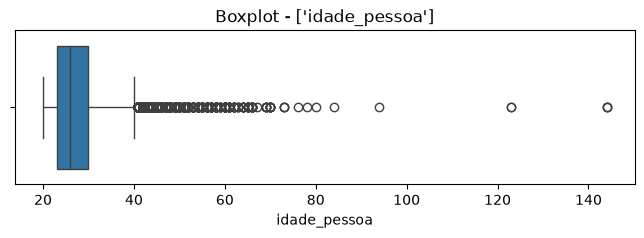

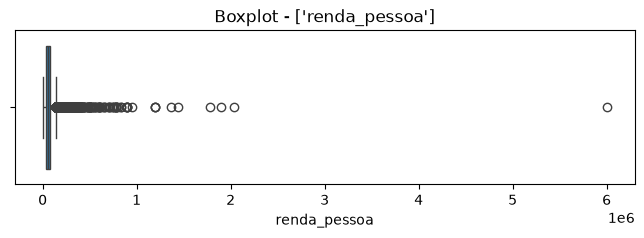

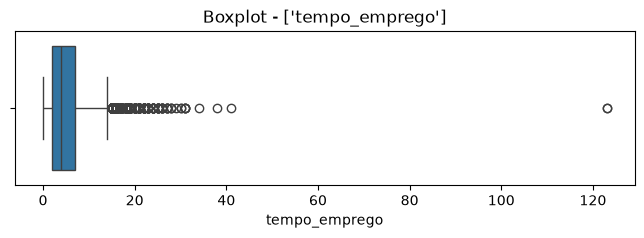

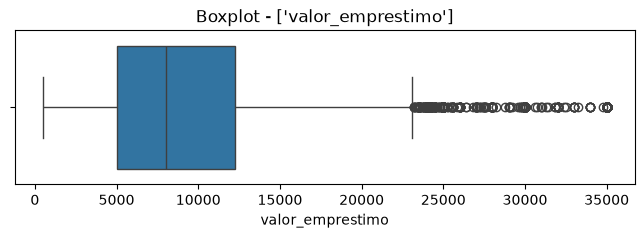

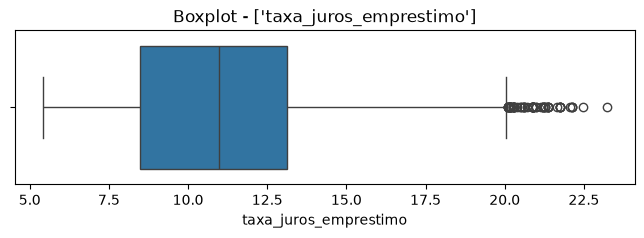

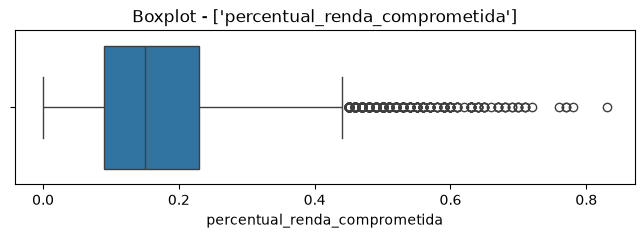

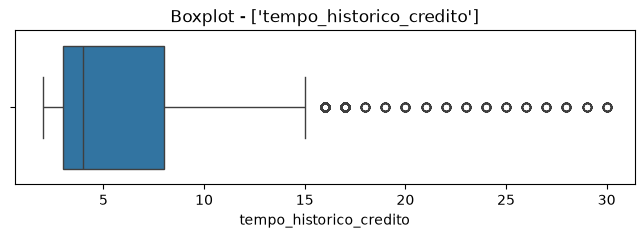

In [109]:
# Iniciei com a plotagem para os boxplot

colunas_numericas = [
    'idade_pessoa',
    'renda_pessoa',
    'tempo_emprego',
    'valor_emprestimo',
    'taxa_juros_emprestimo',
    'percentual_renda_comprometida',
    'tempo_historico_credito'
]

for coluna in colunas_numericas:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[coluna])

    plt.title(f'Boxplot - {[coluna]}')

    plt.show()

In [110]:
%pip install plotly --default-timeout=100


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Busquei um gráfico para melhor analisar e entender esses dados para a aplicação futura dos modelos.
O Uso do Plotly para Análise Visual para melhor entender informações discrepantes (outliers).


In [111]:
import plotly.express as px

fig_idade = px.box(
    df, 
    x="idade_pessoa", 
    title="Auditoria Interativa: Idade da Pessoa (Passe o mouse nas bolinhas)",
    points="outliers"
)
fig_idade.update_traces(marker_color='skyblue')
fig_idade.show()

In [112]:
#import plotly.express as px

#fig_emprego = px.box(
#    df, 
#    x="tempo_emprego", 
#    title="Auditoria Interativa: Tempo de Emprego (Passe o mouse nas bolinhas)",
#    points="outliers"
#)
#fig_emprego.update_traces(marker_color='salmon')
#fig_emprego.show()

In [113]:
#import plotly.express as px

#fig_renda = px.box(
#    df, 
#    x="renda_pessoa", 
#    title="Auditoria Interativa: Renda Anual (Passe o mouse nas bolinhas)",
#    points="outliers"
#)
#fig_renda.update_traces(marker_color='lightgreen')
#fig_renda.show()

In [114]:
#import plotly.express as px

#fig_valor = px.box(
#    df, 
#    x="valor_emprestimo", 
#    title="Auditoria Interativa: Valor do Empréstimo Solicitado",
#    points="outliers"
#)
#fig_valor.update_traces(marker_color='gold')
#fig_valor.show()

In [115]:
#import plotly.express as px

#fig_juros = px.box(
#    df, 
#    x="taxa_juros_emprestimo", 
#    title="Auditoria Interativa: Taxa de Juros do Empréstimo",
#    points="outliers"
#)
#fig_juros.update_traces(marker_color='orchid')
#fig_juros.show()

In [116]:
#import plotly.express as px

#fig_comprometimento = px.box(
#    df, 
#    x="percentual_renda_comprometida", 
#    title="Auditoria Interativa: Percentual da Renda Comprometida",
#    points="outliers"
#)
#fig_comprometimento.update_traces(marker_color='aquamarine')
#fig_comprometimento.show()


In [117]:
#import plotly.express as px

#fig_historico = px.box(
#    df, 
#    x="tempo_historico_credito", 
#    title="Auditoria Interativa: Tempo de Histórico de Crédito (Passe o mouse)",
#    points="outliers"
#)
#fig_historico.update_traces(marker_color='orange')
#fig_historico.show()

# Avaliação do Impacto dos Outliers nos Modelos Propostos

Após a análise visual realizada por meio do **Boxplot**, foram identificados valores extremos que podem impactar o desempenho dos modelos propostos. Entre os outliers encontrados, destacam-se dois registros considerados inconsistentes do ponto de vista biológico e profissional: um registro com **144 anos de idade** e outro com **123 anos de tempo de emprego**.

## Decisão Metodológica: Remoção (Drop)

Optei pela **remoção dessas duas observações da base de dados**, pois representam inconsistências impossíveis de serem corrigidas ou interpretadas como cenários reais. Valores dessa natureza podem prejudicar o aprendizado dos algoritmos, principalmente aqueles baseados em cálculo de distância.

Como a base possui mais de **32.000 registros**, a exclusão dessas duas linhas representa uma alteração estatisticamente irrelevante no volume total dos dados, porém contribui para melhorar a qualidade da modelagem, evitando que informações inválidas influenciem os resultados dos modelos.

Os demais outliers identificados, como valores elevados de renda (até aproximadamente **6 milhões**) e taxas de juros de até **23%**, foram **mantidos**, pois podem representar situações reais do mercado financeiro. Esses registros podem conter informações relevantes para a identificação de padrões relacionados ao risco de crédito e, portanto, não devem ser removidos apenas por apresentarem valores elevados.

## Impacto nos Modelos Propostos

### 1. Árvore de Decisão

A presença de outliers possui menor impacto na **Árvore de Decisão**, pois esse algoritmo realiza previsões através de regras baseadas em divisões dos dados, como valores maiores ou menores que determinados limites.

Diferentemente de algoritmos baseados em distância, a Árvore de Decisão não calcula proximidade entre registros e, por isso, valores extremos não alteram diretamente a escala das variáveis utilizadas pelo modelo.

Dessa forma, os outliers considerados possíveis, como rendas elevadas e taxas de juros maiores, foram mantidos para que o algoritmo possa aprender padrões reais presentes no mercado de crédito.

### 2. KNN (K-Nearest Neighbors)

O impacto dos outliers é mais relevante no algoritmo **KNN (K-Nearest Neighbors)**, pois seu funcionamento depende do cálculo de distância entre os registros, utilizando normalmente a **distância euclidiana** para identificar os vizinhos mais próximos.

Valores extremos podem aumentar artificialmente a distância entre observações e fazer com que determinadas variáveis tenham maior influência no cálculo, prejudicando a identificação dos registros realmente semelhantes.

Por esse motivo, foram removidos os outliers considerados erros de dados, como a idade de **144 anos** e o tempo de emprego de **123 anos**. Já os demais valores extremos, que possuem possibilidade de ocorrência real, serão mantidos e terão seu impacto tratado posteriormente na **Fase 4**, através da aplicação de técnicas de escalonamento, como o **StandardScaler**, que permite colocar as variáveis em uma escala comparável.

Essa abordagem busca preservar informações importantes da base, eliminando apenas inconsistências que poderiam prejudicar o aprendizado dos modelos.


In [118]:
# 1. Guardando a quantidade de linhas original
linhas_antes = df.shape[0]

# 2. Aplicando os filtros 
# Manter apenas idades menores que 100 anos e tempo de emprego menor que 70 anos
df = df[(df['idade_pessoa'] < 100) & (df['tempo_emprego'] < 70)]

# 3. Guardando a quantidade de linhas após a limpeza
linhas_depois = df.shape[0]
linhas_removidas = linhas_antes - linhas_depois

# 4. Exibindo os resultados para comprovar a limpeza ao professor
print("=== RELATÓRIO DE TRATAMENTO DE OUTLIERS ===")
print(f"Quantidade de linhas antes do tratamento: {linhas_antes}")
print(f"Quantidade de linhas após a remoção:     {linhas_depois}")
print(f"Total de registros inválidos eliminados: {linhas_removidas}")
print("-" * 43)
print(f"Nova Idade Máxima na base:            {df['idade_pessoa'].max()} anos")
print(f"Novo Tempo de Emprego Máximo na base: {df['tempo_emprego'].max()} anos")

=== RELATÓRIO DE TRATAMENTO DE OUTLIERS ===
Quantidade de linhas antes do tratamento: 32416
Quantidade de linhas após a remoção:     32409
Total de registros inválidos eliminados: 7
-------------------------------------------
Nova Idade Máxima na base:            94 anos
Novo Tempo de Emprego Máximo na base: 41.0 anos


---

Fase 3:

*  Criar obrigatoriamente uma nova coluna numérica combinando variáveis existentes por meio de operadores matemáticos. Atenção: Trate os nulos das colunas originais antes do cálculo para evitar contaminação por valores NaN ou infinitos. No caso de escolha da Base A (Crédito): crie a coluna comprometimento_renda = (loan_amnt / person_income) * 100. 

In [119]:
# Criação da coluna: comprometimento_renda

# Checagem de valores nulos nas colunas utilizadas
df[['valor_emprestimo', 'renda_pessoa']].isnull().sum()

valor_emprestimo    0
renda_pessoa        0
dtype: int64

In [120]:
# Evitar divisão por zero
df = df[df['renda_pessoa'] > 0]

# Criando a nova variável
df['comprometimento_renda'] = (
    df['valor_emprestimo'] / df['renda_pessoa']
) * 100

# Conferindo o resultado
df[['valor_emprestimo',
    'renda_pessoa',
    'comprometimento_renda']].head()

,valor_emprestimo,renda_pessoa,comprometimento_renda
1,1000,9600,10.416667
2,5500,9600,57.291667
3,35000,65500,53.435115
4,35000,54400,64.338235
5,2500,9900,25.252525


Fase 3 (Feature Engineering)

Foi criada a variável comprometimento_renda, o quanto da renda do cliente está comprometida com o empréstimo solicitado. Em vez de o modelo analisar separadamente a renda e o valor do empréstimo, ele passa a receber uma informação mais significativa para prever inadimplência.

Antes do cálculo, foram tratados os valores nulos das colunas utilizadas e removidos registros com renda igual a zero, evitando valores inválidos (NaN ou infinito) durante a divisão.

---

Fase 4: Separação, Balanceamento e Escalonamento Seguro 
<br><br><br>
Fase 4

* Encoding: converta colunas textuais/categóricas em formato numérico utilizando técnicas adequadas (como One-Hot Encoding ou Label Encoding). 

In [121]:
df.dtypes

idade_pessoa                       int64
renda_pessoa                       int64
tipo_residencia                      str
tempo_emprego                    float64
finalidade_emprestimo                str
classificacao_emprestimo             str
valor_emprestimo                   int64
taxa_juros_emprestimo            float64
status_emprestimo                  int64
percentual_renda_comprometida    float64
historico_inadimplencia              str
tempo_historico_credito            int64
comprometimento_renda            float64
dtype: object

Para fins de decisão sobre a escolha desta etapa, irei investigar o conteúdo das colunas a serem transformadas.

In [122]:
# Identificando as colunas categóricas
colunas_categoricas = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("Colunas categóricas encontradas:")
print(colunas_categoricas)

# Exibindo as categorias existentes em cada coluna
for coluna in colunas_categoricas:
    print(f"\n{'='*50}")
    print(f"Coluna: {coluna}")
    print(f"{'='*50}")

    display(
        pd.DataFrame(
            df[coluna].value_counts()
        ).rename(columns={coluna: "Quantidade"})
    )

Colunas categóricas encontradas:
['tipo_residencia', 'finalidade_emprestimo', 'classificacao_emprestimo', 'historico_inadimplencia']

Coluna: tipo_residencia


,count
tipo_residencia,
RENT,16374
MORTGAGE,13366
OWN,2563
OTHER,106



Coluna: finalidade_emprestimo


,count
finalidade_emprestimo,
EDUCATION,6409
MEDICAL,6042
VENTURE,5679
PERSONAL,5496
DEBTCONSOLIDATION,5189
HOMEIMPROVEMENT,3594



Coluna: classificacao_emprestimo


,count
classificacao_emprestimo,
A,10702
B,10384
C,6436
D,3619
E,963
F,241
G,64



Coluna: historico_inadimplencia


,count
historico_inadimplencia,
N,26680
Y,5729


Justificativa da técnica de Encoding

Optei pelo **One-Hot Encoding** para transformar as variáveis categóricas em numéricas, pois as categorias presentes na base representam informações nominais, sem uma relação de ordem entre si.

O Label Encoding, que atribui um número inteiro para cada categoria, pode induzir uma ordem artificial entre os valores, o One-Hot Encoding cria uma coluna binária para cada categoria, preservando seu significado e evitando que o modelo interprete uma categoria como maior ou menor que outra.

Essa abordagem é especialmente adequada para variáveis como tipo de residência, finalidade do empréstimo, classificação do empréstimo e histórico de inadimplência, permitindo que os algoritmos de Machine Learning utilizem essas informações sem introduzir relações inexistentes entre as categorias.

In [123]:
# Ajuste do include para buscar 'object', 'category' e 'string'
colunas_categoricas = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"Colunas textuais encontradas para Encoding: {colunas_categoricas}")

# Aplicando o One-Hot Encoding
df_codificado = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

# Verificando o novo formato da base
print("\n=== VERIFICAÇÃO APÓS ENCODING ===")
print(f"Tamanho da base antes: {df.shape}")
print(f"Tamanho da base agora: {df_codificado.shape}")
print(f"Novas colunas criadas: [{(df_codificado.shape[1] - df.shape[1]) + len(colunas_categoricas)} colunas adicionadas]")


# VERIFIR AS CATEGORIAS DE REFERÊNCIA (drop_first)
# =======================================================

for coluna in colunas_categoricas:
    print(f"\nColuna original: {coluna}")

    # Categorias antes do Encoding (ordenadas)
    categorias_originais = sorted(df[coluna].unique())

    # Colunas criadas após o One-Hot
    colunas_criadas = [
        c.replace(f"{coluna}_", "")
        for c in df_codificado.columns
        if c.startswith(f"{coluna}_")
    ]

    # Categoria removida
    categoria_referencia = list(set(categorias_originais) - set(colunas_criadas))

    print(f"Categorias originais: {categorias_originais}")
    print(f"Colunas criadas: {colunas_criadas}")
    print(f"Categoria removida (referência): {categoria_referencia[0]}")

Colunas textuais encontradas para Encoding: ['tipo_residencia', 'finalidade_emprestimo', 'classificacao_emprestimo', 'historico_inadimplencia']

=== VERIFICAÇÃO APÓS ENCODING ===
Tamanho da base antes: (32409, 13)
Tamanho da base agora: (32409, 24)
Novas colunas criadas: [15 colunas adicionadas]

Coluna original: tipo_residencia
Categorias originais: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
Colunas criadas: ['OTHER', 'OWN', 'RENT']
Categoria removida (referência): MORTGAGE

Coluna original: finalidade_emprestimo
Categorias originais: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
Colunas criadas: ['EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
Categoria removida (referência): DEBTCONSOLIDATION

Coluna original: classificacao_emprestimo
Categorias originais: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Colunas criadas: ['B', 'C', 'D', 'E', 'F', 'G']
Categoria removida (referência): A

Coluna original: historico_inadimplencia
Categorias orig

Encoding

Para que os algoritmos matemáticos do KNN e da Árvore de Decisão consigam processar as variáveis qualitativas/categóricas da nossa base de dados, realizei o processo de **Encoding**. 

**Técnica Escolhida:**  **One-Hot Encoding** (via função `pd.get_dummies`), aplicando o parâmetro `drop_first=True`. Essa abordagem transforma cada categoria de texto em colunas binárias independentes contendo valores $0$ ou $1$. A remoção da primeira categoria correlacionada (`drop_first=True`) é uma prática essencial de mercado para evitar a redundância de dados (multicolinearidade), garantindo estabilidade matemática aos modelos preditivos sem perda de poder de informação.

Fase 4

* Split de Dados: Separe as variáveis preditoras (X) do alvo (y) e divida em Treino e Teste (test_size=0.20), aplicando o parâmetro stratify=y para preservar a proporção das classes.

In [124]:
from sklearn.model_selection import train_test_split

# 1. Separ o Alvo (y) das variáveis preditoras (X)
# O nosso alvo é identificar quem é inadimplente (1) e quem paga em dia (0)
y = df_codificado['status_emprestimo']
X = df_codificado.drop(columns=['status_emprestimo'])

# 2. Divide em Treino (80%) e Teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, 
    test_size=0.20,      # Reserva 20% para o teste às cegas
    random_state=42,     # Garante que o resultado seja sempre o mesmo ao rodar
    stratify=y           # REGRA: Preserva a proporção das classes
)

print("=== DIVISÃO DOS DADOS CONCLUÍDA ===")
print(f"Tamanho de X_treino (Base de Estudo): {X_treino.shape}")
print(f"Tamanho de X_teste (Base de Prova):   {X_teste.shape}")
print(" Proporção de classes no Treino (y_treino):")
print(y_treino.value_counts(normalize=True))
print(" Proporção de classes no Teste (y_teste):")
print(y_teste.value_counts(normalize=True))

=== DIVISÃO DOS DADOS CONCLUÍDA ===
Tamanho de X_treino (Base de Estudo): (25927, 23)
Tamanho de X_teste (Base de Prova):   (6482, 23)
 Proporção de classes no Treino (y_treino):
status_emprestimo
0    0.781309
1    0.218691
Name: proportion, dtype: float64
 Proporção de classes no Teste (y_teste):
status_emprestimo
0    0.78124
1    0.21876
Name: proportion, dtype: float64


# Fase 4: Divisão dos Dados em Treino e Teste (Split)

Para garantir uma validação justa, robusta e realista, realizei a separação do conjunto de dados em duas partes totalmente independentes utilizando a função `train_test_split` do scikit-learn:

1.Base de Treino (80%): Destinada exclusivamente ao aprendizado e ajuste dos algoritmos (KNN e Árvore de Decisão). <br>
2.Base de Teste (20%): Reservada como dados inéditos, funcionando como uma "prova às cegas" para avaliar a verdadeira capacidade de generalização do modelo quando ele lidar com novos clientes.

**Importância do Parâmetro `stratify=y`:** Como a nossa variável alvo (`status_emprestimo`) é altamente desbalanceada (existem muito mais bons pagadores do que inadimplentes), a aplicação da estratificação é um requisito crítico. Esse parâmetro força o algoritmo a espelhar a mesma proporção percentual exata de pagadores e inadimplentes tanto no conjunto de treino quanto no de teste. Isso evita o risco de criarmos uma base de teste sem exemplos de calotes, o que invalidaria a avaliação financeira e de negócios exigida pelo projeto.